In [2]:
import numpy as np # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
import matplotlib_inline # to edit the inline plot format
#matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg') # to make plots in pdf (vector) format
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import uproot # for reading .root files
import awkward as ak # to represent nested data in columnar format
import vector # for 4-momentum calculations
import time # for printing time stamps
import requests # for file gathering, if needed

In [3]:
MeV = 0.001
GeV = 1.0
import atlasopenmagic as atom
atom.available_releases()
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 798.01datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [70]:
skim = "exactly4lep"

In [ ]:
# not used
defs = {
    r'Data':{'dids':['data']},
    r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':{'dids': [410470,410155,410218,
                                                        410219,412043,364243,
                                                        364242,364246,364248,
                                                        700320,700321,700322,
                                                        700323,700324,700325], 'color': "#6b59d3" }, # purple
    r'Background $ZZ^{*}$':     {'dids': [700600],'color': "#ff0000" },# red
    r'Signal ($m_H$ = 125 GeV)':  {'dids': [345060, 346228, 346310, 346311, 346312,
                                          346340, 346341, 346342],'color': "#00cdff" },# light blue
}

samples   = atom.build_dataset(defs, skim=skim, protocol='https', cache=True)

In [6]:
data15_periodD = samples['Data']['list'][0]
print(f"{data15_periodD = }")

data15_periodD = 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root'


In [7]:
!pip install requests aiohttp
#tree = uproot.open(data15_periodD + ":analysis")

In [89]:
tree = uproot.open(data15_periodD + ":analysis")
print(tree.num_entries)
print(tree.keys())
print(tree.arrays())

3424
['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMediumID', 'lep_isLooseID', 'lep_isTightIso', 'lep_isLooseIso', 'lep_isTrigMatched', 'ScaleFactor_PHOTON', 'phot

In [90]:
#examine lepton energies
tree["lep_e"].arrays(library="ak")

<Array [{lep_e: [91.3, ..., 23.5]}, ..., {...}] type='3424 * {lep_e: var * ...'>

In [9]:
# define which variables are important to our analysis
variables = ['lep_pt','lep_eta','lep_phi','lep_e','lep_charge','lep_type','trigE','trigM','lep_isTrigMatched',
            'lep_isLooseID','lep_isMediumID','lep_isLooseIso','lep_type']
for data in tree.iterate(variables,library="ak"):
    print(data)

[{lep_pt: [32.4, 11.4, 11.6, 8.2], lep_eta: [-1.7, ...], ...}, ..., {...}]


In [10]:
# do cuts for first event
entry = tree.arrays(library="ak")[:1] # first entry of the tree

# cut on lepton type 
# e- is 11, mu- is 13
lep_type = entry['lep_type']
print(lep_type)
sum_lep_type = lep_type[:,0]+lep_type[:,1]+lep_type[:, 2] + lep_type[:, 3]
print(sum_lep_type)
# we need two pairs of leptons, can either have 4e -> 4*11=44, 4e+2mu-> 22+26=48, 4mu -> 52
# otherwise should be cut
lep_type_cut_bool = (sum_lep_type != 44) & (sum_lep_type != 48) & (sum_lep_type != 52)
print(f"Cut for lepton type?: {lep_type_cut_bool}") #True means we cut

# cut on lepton charge
# first lepton in each event is [:,0], 2nd lepton is [:,1], etc.
lep_charge = entry['lep_charge']
sum_lep_charge = lep_charge[:,0] + lep_charge[:,1] + lep_charge[:,2] + lep_charge[:,3]
lep_charge_cut_bool = (sum_lep_charge != 0)
print(f"Cut for lepton charge?: {lep_charge_cut_bool}")

# calculate invariant mass of the 4-lep state
p4 = vector.zip({"pt":entry['lep_pt'], "eta": entry['lep_eta'], "phi": entry['lep_phi'], "E": entry['lep_e']})
invar_mass = (p4[:,0]+p4[:,1] + p4[:,2] + p4[:,3]).M
print(p4[:,0])
print(f"Invariant mass: {invar_mass}")

[[11, 11, 11, 13]]
[46]
Cut for lepton type?: [True]
Cut for lepton charge?: [False]
[{rho: 32.4, phi: 1.7, eta: -1.7, t: 91.3}]
Invariant mass: [5.6]


In [95]:
# write functions for cuts
def cut_lep_type(lep_type):
    sum_lep_type = lep_type[:,0]+lep_type[:,1]+lep_type[:, 2] + lep_type[:, 3]
    lep_type_cut_bool = (sum_lep_type != 44) & (sum_lep_type != 48) & (sum_lep_type != 52)
    return lep_type_cut_bool # true means cut

def cut_lep_charge(lep_charge):
    # first lepton in each event is [:, 0], 2nd lepton is [:, 1] etc
    sum_lep_charge = lep_charge[:, 0] + lep_charge[:, 1] + lep_charge[:, 2] + lep_charge[:, 3] != 0
    return sum_lep_charge # True means we should remove this entry (sum of lepton charges is not equal to 0)

def calc_mass(lep_pt,lep_eta,lep_phi,lep_e):
    p4 = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e})
    invar_mass = (p4[:,0]+p4[:,1] + p4[:,2] + p4[:,3]).M
    return invar_mass

# this catches if the lepton that the event was triggered on matches one of the 4 leptons we care about
def cut_trig_match(lep_trigmatch):
    trigmatch = lep_trigmatch
    cut1 = ak.sum(trigmatch,axis=1) >= 1
    return cut1

# see if we trigger on either muon or electron
def cut_trig(trigE,trigM):
    return trigE | trigM

# check if all four lepton matches isolation and identification criteria
# these criteria ensure that the lepton signature isn't a background from a jet or other process
def ID_iso_cut(IDel,IDmu,isoel,isomu,pid):
    thispid = pid
    return (ak.sum(((thispid == 13) & IDmu & isomu) | ((thispid == 11) & IDel & isoel), axis=1) == 4)

In [91]:
# empty list to hold all data for this simple
sample_data = []

# do cuts for each data entry in tree (each event)
for data in tree.iterate(variables,library="ak"): #data in awk array
    lep_type = data['lep_type']
    # look at available columns
    print(data.fields)
    # use data[~bool] to remove entries from dataset
    # by passing a boolean array to an awkward array, it drops every entry that is False
    print(f"Events before cut: {len(data)}")
    data = data[~cut_lep_type(lep_type)]
    lep_charge = data['lep_charge']
    data = data[~cut_lep_charge(lep_charge)]
    print(f"Events after cut: {len(data)}")

    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    
    sample_data.append(data)

data_A = ak.concatenate(sample_data)


['lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_type', 'trigE', 'trigM', 'lep_isTrigMatched', 'lep_isLooseID', 'lep_isMediumID', 'lep_isLooseIso']
Events before cut: 3424
Cut for lepton type?: [True, False, False, True, False, True, ..., False, False, False, False, False]
Events after cut: 861
Invariant mass: [117, 262, 1.31, 15.6, 0.734, 53.2, 73.4, ..., 3.04, 39.4, 33.4, 155, 22.4, 14]


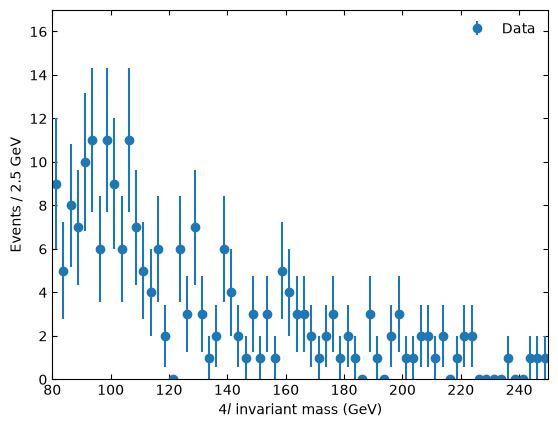

In [29]:
# time to plot the data for these 861 events
xmin = 80 * GeV
xmax = 250 * GeV

step_size = 2.5 * GeV
bin_edges = np.arange(start=xmin,stop=xmax+step_size,step=step_size)
bin_centers = np.arange(start=xmin+step_size/2,stop=xmax+step_size/2,step=step_size)

data_x,_ = np.histogram(ak.to_numpy(data_A['mass']),bins=bin_edges)
data_x_errors = np.sqrt(data_x) # statistical error

# make plot
plot = plt.gca()
plot.errorbar(x=bin_centers,y=data_x,yerr=data_x_errors,fmt='o',label='Data')
plot.set_xlim(left=xmin,right=xmax)
plot.set_ylim(0,17)
#plt.hist(data_A['mass'])
#plt.xlim(xmin,xmax)
plot.tick_params(which='both',direction='in',top=True,right=True)
plot.set_xlabel(r'4$l$ invariant mass (GeV)')
plot.set_ylabel('Events / ' + str(step_size) + ' GeV')
plot.legend(frameon=False)

In [79]:
# Now let us read the MC data to compare theoretical data points to data
# the MC data was simulated with ideal circumstances, but the real detector has inefficiencies
# handle this by attributing an appropriate weight to each data point

#open an MC data file with simulated ttbar events, data set ID 410470
value = samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']["list"][0]
print(value)

background_ttbar_path = value
tree = uproot.open(background_ttbar_path+":analysis")

simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410470.PhPy8EG_A14_ttbar_hdamp258p75_nonallhad.exactly4lep.root


In [80]:
# the weights which are important to our analysis are the scale factors for:
# pileup reweighting, electron and muon efficiency, lepton triggers
weight_variables = ["filteff","kfac","xsec","mcWeight","ScaleFactor_PILEUP","ScaleFactor_ELE","ScaleFactor_MUON","ScaleFactor_LepTRIGGER"]
#tree["ScaleFactor_MUON"].arrays(library='ak')
print(weight_variables)

lumi = 0.105 #luminosity of periodD in data 15, fb-1
# luminosity cheatsheat: https://www.google.com/url?q=https%3A%2F%2Fcds.cern.ch%2Frecord%2F2800578%2Ffiles%2FCross%2520Section%2520and%2520Luminosity%2520Physics%2520Cheat%2520Sheet.pdf

#use first event of tree
event = tree.arrays()[0]
# now calculate total cross section weight
# tot weight = luminosity * cross section (xsec) * filter effiency(filteff) * k factor (kfac, high order theoretical calc effects) * weights added to event by generator (mcweight) / sum of weights
tot_weight = lumi * 1000 / event["sum_of_weights"] #1000 is because cross section in pb-1
for var in weight_variables:
    tot_weight = tot_weight * event[var]
print(f"{tot_weight = }")
# this means that in the final histogram, the event will be represented as 0.00173 of a single count in the bin

['filteff', 'kfac', 'xsec', 'mcWeight', 'ScaleFactor_PILEUP', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER']
tot_weight = np.float64(0.0017336209613845047)


In [44]:
# now generalize this calc in a function for any event
def calc_weight(weight_vars,events):
    total_weight = lumi * 1000 / events["sum_of_weights"]
    for var in weight_vars:
        total_weight = total_weight * abs(events[var])
    return total_weight

print(calc_weight(weight_variables,event))
# should get same answer for the weight of event 0

0.0017336209613845047


In [46]:
# now apply same cuts before so we can plot the MC data. 
# same code as before, but we add weight_variables to tree.iterate() and store weights in each event using new dictionary key

mc_data = [] # will store data after cuts in this list
# need to understand what this tree.iterate object structure is
for data in tree.iterate(variables + weight_variables + ['sum_of_weights'], library='ak'): #use all variables for cuts + weight variables
    print(f"Num of events before cuts: {len(data)}")
    lep_type   = data['lep_type']
    data = data[~cut_lep_type(lep_type)]
    lep_charge = data['lep_charge'] # this line needs to come after the first cut so the length of the array matches
    data = data[~cut_lep_charge(lep_charge)]

    print(f"Num of events after cuts: {len(data)}")
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])

    data['totalWeight'] = calc_weight(weight_variables, data)

    mc_data.append(data)

bg_ttbar = ak.concatenate(mc_data)



Num of events before cuts: 13763
Cut for lepton type?: [True, True, True, True, True, True, ..., True, True, True, True, True, False]
Num of events after cuts: 3707
Invariant mass: [123, 118, 126, 190, 91.1, 121, 138, ..., 230, 153, 132, 172, 56.8, 184, 50.8]


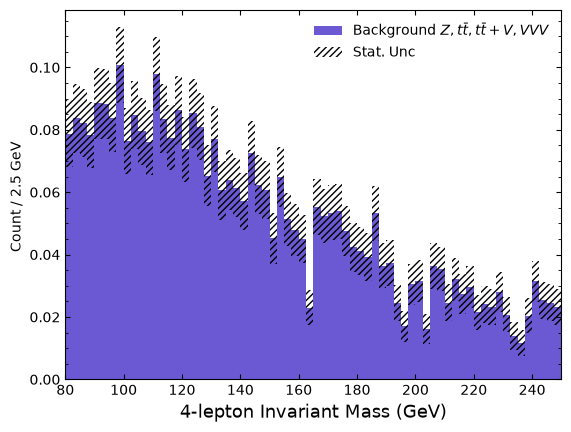

In [59]:
# plot MC data

stepsize = 2.5 # GeV

mc_x = ak.to_numpy(bg_ttbar['mass']) #list to hold MC invar mass entries
# what was structure of the awkward array before we flattened it?
mc_weights = ak.to_numpy(bg_ttbar['totalWeight'])
mc_labels = r'Background $Z, t\bar{t}, t\bar{t}+V,VVV$'
mc_colors = samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['color'] #what is going on here?

# plot
plot = plt.gca()
mc_heights = plot.hist(mc_x,bins=bin_edges,weights=mc_weights,stacked=True,color=mc_colors,label=mc_labels)
mc_x_tot = mc_heights[0] # stacked background MC y-axis val
#MC stat uncertainty is sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x),bins=bin_edges,weights=np.hstack(mc_weights)**2)[0])

# plot uncertainty
plot.bar(bin_centers, #x
            2*mc_x_err, #heights
            alpha=0.5, color='none',hatch="/////",
            bottom=mc_x_tot-mc_x_err, width=step_size,label='Stat. Unc')

plot.set_xlabel("4-lepton Invariant Mass (GeV)",fontsize=13)
plot.set_ylabel(f"Count / {step_size} GeV ")
plot.legend(frameon=False)
plot.set_xlim(left=xmin,right=xmax)
plot.tick_params(which='both',direction='in',right=True,top=True)
plot.yaxis.set_minor_locator(AutoMinorLocator())

In [97]:
# now we wil do the full analysis by looping over all the samples in the samples dictionary
#depending on if the sample is a data sample or MC sample, fileString will change
# cuts, mass calcs, and MC weight calcs will be performed for each sample value and stored in the array
# data is all concatenated into all_data for plot

lumi = 36.6 #fb-1, data size of full release
fraction = 1.0 #for runtime
all_data = {} #dictionary for awkward arrays

#loop over samples, samples structure illustrated below
# samples is a dictionary with 4 keys: data, two bg's and signal
# each sample has a list of files, data has 16, mc signal has 8, etc.
for s in samples:
    print("Processing "+s+" samples")
    frames = [] #empty list for holding data
    #loop over each file
    for file in samples[s]['list']:
        if s=='Data':
            print("Processing this data file:")
            prefix = "Data/"
        else:
            print("this is an MC file")
            prefix = "Mc/mc_"
        
        # start clock for timing
        start = time.time()
        print("\t"+file+":")

        tree = uproot.open(file+":analysis")

        sample_data = []

        #loop over all data in the tree
        for data in tree.iterate(variables+weight_variables+["sum_of_weights","lep_n"],
                                library="ak",entry_stop=tree.num_entries*fraction):
            num_before = len(data)
            print("\t"+"Num events in this batch: "+str(num_before))

            #now we will make the cuts on the data
            #first cuts are from trigger, if leptons were triggered on and if the triggered leptons match the 4 we look at
            data=data[cut_trig(data.trigE,data.trigM)]
            data=data[cut_trig_match(data.lep_isTrigMatched)]
            print("\t"+"Num events after trigger cuts: "+str(len(data)))

            #make cuts on tranverse mom
            data = data[data['lep_pt'][:,0] > 20] # keep if leading lep pt > 20 GeV
            data = data[data['lep_pt'][:,1] > 15] # second highest lep pt> 15 GeV
            data = data[data['lep_pt'][:,2] > 10]
            print("\t"+"Num events after pt cuts: "+str(len(data)))

            #cuts to make sure lepton isn't BG: iso+ID
            data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]
            print("\t"+"Num events after iso/ID cuts: "+str(len(data)))
            
            #lepton charge and type cuts
            lep_type = data['lep_type']
            data = data[~cut_lep_type(lep_type)]
            lep_charge = data['lep_charge']
            data = data[~cut_lep_charge(lep_charge)]
            print("\t"+"Num events after lepton cuts: "+str(len(data)))

            #calculate mass
            data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
            
            #if MC, store weights in output
            if 'data' not in s:
                data['totalWeight'] = calc_weight(weight_variables,data)

            sample_data.append(data)        
            if not 'data' in file:
                num_after = sum(data['totalWeight']) # sum of weights passing cuts in this batch
            else:
                num_after = len(data)
            
            end = time.time() 
            elapsed = end - start
            print("\t\t nIn: "+str(num_before)+",\t nOut: \t"+str(num_after)+"\t in "+str(round(elapsed,1))+"s")
            
        
        frames.append(ak.concatenate(sample_data))
    
    all_data[s] = ak.concatenate(frames)

print(all_data)



        



Processing Data samples
Processing this data file:
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
	Num events in this batch: 3424
	Num events after trigger cuts: 395
	Num events after pt cuts: 110
	Num events after iso/ID cuts: 2
	Num events after lepton cuts: 2
		 nIn: 3424,	 nOut: 	2	 in 0.2s
Processing this data file:
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
	Num events in this batch: 25092
	Num events after trigger cuts: 3420
	Num events after pt cuts: 765
	Num events after iso/ID cuts: 20
	Num events after lepton cuts: 17
		 nIn: 25092,	 nOut: 	17	 in 0.8s
Processing this data file:
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
	Num events in this batch: 16234
	Num events after trigger cuts: 2242
	Num events after pt 

In [67]:
for s in samples:
    print(s)
    print(len(samples[s]['list']))
    #print(samples[s]['list'])
print(samples)

Data
16
Background $Z,t\bar{t},t\bar{t}+V,VVV$
15
Background $ZZ^{*}$
1
Signal ($m_H$ = 125 GeV)
8
{'Data': {'list': ['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata

In [87]:
samples   = atom.build_dataset(defs, skim=skim, protocol='https', cache=True)
for i,batch in enumerate(samples['Data']['list']):
    thistree = uproot.open(batch+':analysis')
    for data in thistree.iterate(variables,library="ak"): #data in awk array
        lep_type = data['lep_type']
        print(f"Num events in tree {i}: {len(data)}")

Num events in tree 0: 3424
Num events in tree 1: 25092
Num events in tree 2: 16234
Num events in tree 3: 37101
Num events in tree 4: 12152
Num events in tree 5: 67630
Num events in tree 6: 29275
Num events in tree 7: 72544
Num events in tree 8: 91124
Num events in tree 9: 174618
Num events in tree 10: 54896
Num events in tree 11: 118615
Num events in tree 12: 134798
Num events in tree 13: 205285
Num events in tree 14: 84130
Num events in tree 15: 235693


Text(100, 60, '$\\sqrt{s}$ = 13 TeV, $\\int L dt =$ 36.6fb$^{-1}$')

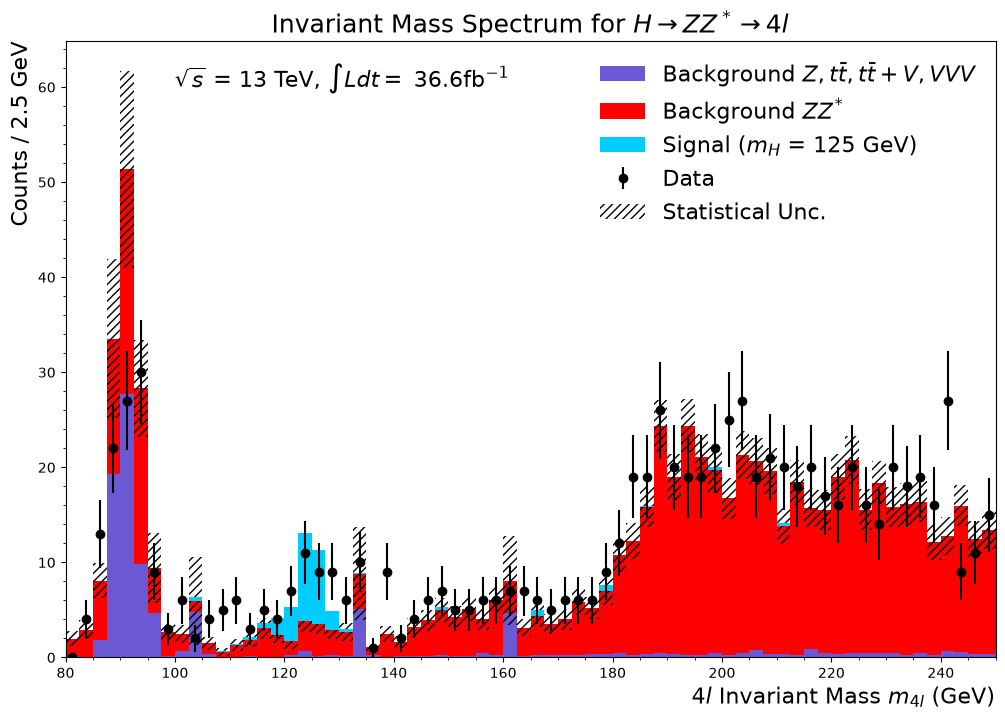

In [135]:
# now make plot of all final data

# histograms for data
# why do i need to use np.histogram for the data but not for the MC?
# because of the weights?
data_x,_ = np.histogram(ak.to_numpy(all_data['Data']['mass']),bins=bin_edges)
data_x_err = np.sqrt(data_x) # statistical error

#histogram for MC signal
signal_x = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['mass'])
# may need to use .totalWeight instead of ['totalWeight']
signal_weights = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['totalWeight'])
signal_color = samples[r'Signal ($m_H$ = 125 GeV)']['color']

#histogram for MC BG
bg_ttbar_x = ak.to_numpy(all_data[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['mass'])
bg_ttbar_weights = ak.to_numpy(all_data[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['totalWeight'])
bg_ttbar_color = samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['color']
bg_ttbar_label = r'Background $Z,t\bar{t},t\bar{t}+V,VVV$'

bg_ZZ_x = ak.to_numpy(all_data[r'Background $ZZ^{*}$']['mass'])
bg_ZZ_weights = ak.to_numpy(all_data[r'Background $ZZ^{*}$']['totalWeight'])
bg_ZZ_color = samples[r'Background $ZZ^{*}$']['color']
bg_ZZ_label = r'Background $ZZ^{*}$'

# mc_x is a list of 2 np arrays
# each array contains the mass values for the events from that bg
mc_x = [bg_ttbar_x,bg_ZZ_x]
mc_weights = [bg_ttbar_weights,bg_ZZ_weights]
mc_color = [bg_ttbar_color,bg_ZZ_color]
mc_labels = [bg_ttbar_label,bg_ZZ_label]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(x=bin_centers,y=data_x,yerr=data_x_err,fmt='ko',label='Data')

#with plt.hist stacked=True, mc_heights returns a tuple
# first entry is histogram heights, 2d array of shape (1, num_bins)
mc_heights = ax.hist(mc_x,bins=bin_edges,weights=mc_weights,
                     stacked=True,color=mc_color,label=mc_labels)

mc_x_tot = mc_heights[0][-1] #this is a 1D array of the MC BG y values

#hstack concatenates the two bgs into a single np array
#histogram the squared weights to get a hist of the variance
mc_weight2,_ = np.histogram(np.hstack(mc_x),bins=bin_edges, weights=np.hstack(mc_weights)**2)
mc_x_err = np.sqrt(mc_weight2)

# plot the uncertainty from the MC bg
ax.bar(bin_centers, #x
       mc_x_err*2, bottom=mc_x_tot-mc_x_err,
       hatch='////',alpha=0.4,width=step_size,
       color='none',label="Statistical Unc.")

#plot the signal bars
ax.hist(signal_x,bins=bin_edges,bottom=mc_x_tot,
        weights=signal_weights,color=signal_color,label=r'Signal ($m_H$ = 125 GeV)')

#plot aesthetics
ax.set_xlim(xmin,xmax)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel(r"$4l$ Invariant Mass $m_{4l}$ (GeV)",fontsize=16,horizontalalignment='right',x=1)
ax.set_ylabel(f'Counts / {step_size} GeV',fontsize=16,horizontalalignment='right',y=1)
ax.legend(frameon=False,fontsize=16)
ax.set_title(r'Invariant Mass Spectrum for $H \rightarrow ZZ^* \rightarrow 4l$',fontsize=18)

plt.text(100,60,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)


